Found 41 subfolders in D:\DataSet: ['2Pc Light Cup (KY-027)', 'Analog Hall (KY-035)', 'Analog Temp (KY-013)', 'Arduino Uno', 'Avoidance (KY-032)', 'Ball Switch (KY-020)', 'Big Sound (KY-037)', 'Button (KY-004)', 'Buzzer (KY-012)', 'Color Flash (KY-0347)', 'Digital Temperature (KY-028)', 'ESP 32', 'ESP 32 Camera', 'ESP 8266', 'Flame (KY-026)', 'GSM Module', 'Hall Magnetic (KY-003)', 'Heartbeat (KY-039)', 'IR Emission (KY-005)', 'IR receiver (KY-022)', 'Joystick (KY-023)', 'Laser Emit (KY-008)', 'Light Blocking (KY-010)', 'Linear Hall (KY-024)', 'Mini Switch (KY-021)', 'Mini Two-Colour(KY-029)', 'Photoresistor (KY-018)', 'Reed Switch (KY-025)', 'Relay (KY-019)', 'RGB LED (KY-016)', 'Rotay Encoders (KY-040)', 'Shock (KY-002)', 'Small Sound (KY-038)', 'SMD RGB (KY-009)', 'Tap Module (KY-031)', 'Temp 18B20 (KY-001)', 'Temp and Humidity (KY-015)', 'Tilt Switch (KY-017)', 'Touch (KY-036)', 'Tracking (KY-033)', 'Two-Colour(KY-011)']
Epoch 1/30, Loss: 18.6671
Epoch 2/30, Loss: 12.8381
Epoch 3/3

ValueError: x and y must have same first dimension, but have shapes (30,) and (0,)

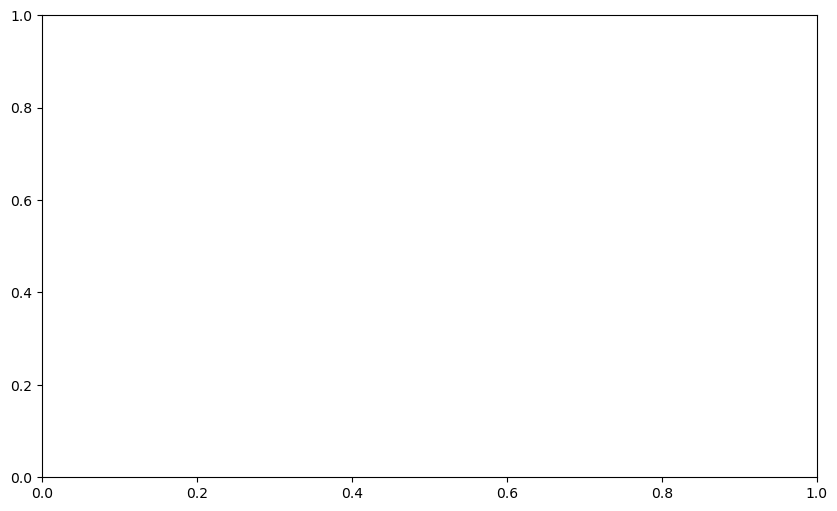

In [25]:
import os
import torch
import open_clip
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CLIP model and tokenizer
model, preprocess, *_ = open_clip.create_model_and_transforms("ViT-B/32-quickgelu", pretrained="openai")
model = model.to(device)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

# Dataset path
dataset_path = r"D:\DataSet"

# Class labels for all 41 folders with specific descriptions
class_labels = [
    "small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027)",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-035)",
    "analog temperature sensor with black thermistor and two pins on green PCB (KY-013)",
    "arduino microcontroller board with blue PCB, USB port, and black IC chips (Uno)",
    "infrared obstacle avoidance sensor with two black IR LEDs and three pins on green PCB (KY-032)",
    "tilt ball switch sensor with metal ball in clear plastic tube on green PCB (KY-020)",
    "microphone sound detection sensor with small round silver mic on red PCB (KY-037)",
    "push button switch module with square black tactile button and four pins on green PCB (KY-004)",
    "active buzzer sound module with black cylindrical piezo and two pins on green PCB (KY-012)",
    "color flash LED module with flashing LED on green PCB (KY-0347)",
    "digital temperature sensor with black chip and three pins on green PCB (KY-028)",
    "ESP32 microcontroller board with black PCB and multiple pins",
    "ESP32 camera module with small camera lens and black PCB",
    "ESP8266 microcontroller board with black PCB and Wi-Fi antenna",
    "flame sensor with infrared receiver and three pins on green PCB (KY-026)",
    "GSM module with SIM card slot and antenna connector on green PCB",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-003)",
    "heartbeat sensor with finger clip and three pins on green PCB (KY-039)",
    "IR emission module with infrared LED and two pins on green PCB (KY-005)",
    "IR receiver module with black IR sensor and three pins on green PCB (KY-022)",
    "analog joystick controller with black joystick, two orange potentiometers, and five pins on green PCB (KY-023)",
    "laser emit module with red laser diode and three pins on green PCB (KY-008)",
    "light blocking sensor with slotted optical switch and three pins on green PCB (KY-010)",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-024)",
    "mini magnetic reed switch with small magnet and two pins on green PCB (KY-021)",
    "mini two-color LED module with red and green LED on green PCB (KY-029)",
    "photoresistor sensor with light-sensitive resistor and two pins on green PCB (KY-018)",
    "reed switch sensor with magnetic reed and two pins on green PCB (KY-025)",
    "electromagnetic relay module with blue relay, screw terminals, and red PCB (KY-019)",
    "multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-016)",
    "rotary encoder module with black knob and five pins on green PCB (KY-040)",
    "shock sensor with spring and two pins on green PCB (KY-002)",
    "microphone sound detection sensor with small round silver mic on red PCB (KY-038)",
    "multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-009)",
    "tap sensor module with vibration sensor and three pins on green PCB (KY-031)",
    "temperature sensor with black chip and three pins on green PCB (KY-001)",
    "temperature and humidity sensor with blue sensor and three pins on green PCB (KY-015)",
    "mercury tilt switch sensor with small glass tube containing silver mercury on green PCB (KY-017)",
    "capacitive touch sensor module with flat silver touch pad and three pins on green PCB (KY-036)",
    "tracking sensor with infrared sensor and three pins on green PCB (KY-033)",
    "two-color LED module with red and green LED on green PCB (KY-011)"
]

# Folder-to-label mapping for all 41 folders
folder_to_label = {
    '2pc light cup (ky-027)': 'small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027)',
    'analog hall (ky-035)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-035)',
    'analog temp (ky-013)': 'analog temperature sensor with black thermistor and two pins on green PCB (KY-013)',
    'arduino uno': 'arduino microcontroller board with blue PCB, USB port, and black IC chips (Uno)',
    'avoidance (ky-032)': 'infrared obstacle avoidance sensor with two black IR LEDs and three pins on green PCB (KY-032)',
    'ball switch (ky-020)': 'tilt ball switch sensor with metal ball in clear plastic tube on green PCB (KY-020)',
    'big sound (ky-037)': 'microphone sound detection sensor with small round silver mic on red PCB (KY-037)',
    'button (ky-004)': 'push button switch module with square black tactile button and four pins on green PCB (KY-004)',
    'buzzer (ky-012)': 'active buzzer sound module with black cylindrical piezo and two pins on green PCB (KY-012)',
    'color flash (ky-0347)': 'color flash LED module with flashing LED on green PCB (KY-0347)',
    'digital temperature (ky-028)': 'digital temperature sensor with black chip and three pins on green PCB (KY-028)',
    'esp 32': 'ESP32 microcontroller board with black PCB and multiple pins',
    'esp 32 camera': 'ESP32 camera module with small camera lens and black PCB',
    'esp 8266': 'ESP8266 microcontroller board with black PCB and Wi-Fi antenna',
    'flame (ky-026)': 'flame sensor with infrared receiver and three pins on green PCB (KY-026)',
    'gsm module': 'GSM module with SIM card slot and antenna connector on green PCB',
    'hall magnetic (ky-003)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-003)',
    'heartbeat (ky-039)': 'heartbeat sensor with finger clip and three pins on green PCB (KY-039)',
    'ir emission (ky-005)': 'IR emission module with infrared LED and two pins on green PCB (KY-005)',
    'ir receiver (ky-022)': 'IR receiver module with black IR sensor and three pins on green PCB (KY-022)',
    'joystick (ky-023)': 'analog joystick controller with black joystick, two orange potentiometers, and five pins on green PCB (KY-023)',
    'laser emit (ky-008)': 'laser emit module with red laser diode and three pins on green PCB (KY-008)',
    'light blocking (ky-010)': 'light blocking sensor with slotted optical switch and three pins on green PCB (KY-010)',
    'linear hall (ky-024)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-024)',
    'mini switch (ky-021)': 'mini magnetic reed switch with small magnet and two pins on green PCB (KY-021)',
    'mini two-colour(ky-029)': 'mini two-color LED module with red and green LED on green PCB (KY-029)',
    'photoresistor (ky-018)': 'photoresistor sensor with light-sensitive resistor and two pins on green PCB (KY-018)',
    'reed switch (ky-025)': 'reed switch sensor with magnetic reed and two pins on green PCB (KY-025)',
    'relay (ky-019)': 'electromagnetic relay module with blue relay, screw terminals, and red PCB (KY-019)',
    'rgb led (ky-016)': 'multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-016)',
    'rotay encoders (ky-040)': 'rotary encoder module with black knob and five pins on green PCB (KY-040)',
    'shock (ky-002)': 'shock sensor with spring and two pins on green PCB (KY-002)',
    'small sound (ky-038)': 'microphone sound detection sensor with small round silver mic on red PCB (KY-038)',
    'smd rgb (ky-009)': 'multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-009)',
    'tap module (ky-031)': 'tap sensor module with vibration sensor and three pins on green PCB (KY-031)',
    'temp 18b20 (ky-001)': 'temperature sensor with black chip and three pins on green PCB (KY-001)',
    'temp and humidity (ky-015)': 'temperature and humidity sensor with blue sensor and three pins on green PCB (KY-015)',
    'tilt switch (ky-017)': 'mercury tilt switch sensor with small glass tube containing silver mercury on green PCB (KY-017)',
    'touch (ky-036)': 'capacitive touch sensor module with flat silver touch pad and three pins on green PCB (KY-036)',
    'tracking (ky-033)': 'tracking sensor with infrared sensor and three pins on green PCB (KY-033)',
    'two-colour(ky-011)': 'two-color LED module with red and green LED on green PCB (KY-011)'
}

# Debugging dataset structure
subfolders = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print(f"Found {len(subfolders)} subfolders in {dataset_path}: {subfolders}")

# Prepare few-shot training data
train_images = []
train_labels = []

for sensor in subfolders:
    sensor_path = os.path.join(dataset_path, sensor)
    actual_label = folder_to_label[sensor.lower()]
    label_idx = class_labels.index(actual_label)
    
    image_paths = [os.path.join(sensor_path, img) for img in os.listdir(sensor_path) if img.endswith((".jpg", ".png"))]
    # Use up to 5 images per class for few-shot training
    for img_path in image_paths[:5]:
        try:
            image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            train_images.append(image)
            train_labels.append(label_idx)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

# Convert to tensors
train_images = torch.cat(train_images, dim=0)
train_labels = torch.tensor(train_labels, dtype=torch.long).to(device)

# Fine-tune CLIP
model.train()
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

num_epochs = 30
batch_size = 32
epoch_losses = [] 

for epoch in range(num_epochs):
    model.zero_grad()
    total_loss = 0
    for i in range(0, len(train_images), batch_size):
        batch_images = train_images[i:i+batch_size]
        batch_labels = train_labels[i:i+batch_size]
        
        with torch.set_grad_enabled(True):
            image_features = model.encode_image(batch_images)
            text_features = model.encode_text(tokenizer(class_labels).to(device))
            logits = (image_features @ text_features.T)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            model.zero_grad()
            total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Switch to evaluation mode
model.eval()

# Function to classify images
def classify_sensor_images(sensor_folder, text_features):
    image_paths = [os.path.join(sensor_folder, img) for img in os.listdir(sensor_folder) if img.endswith((".jpg", ".png"))]
    scores = []

    for img_path in image_paths:
        try:
            image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            with torch.no_grad():
                image_features = model.encode_image(image)
                similarity = (image_features @ text_features.T).softmax(dim=-1)
            scores.append(similarity.squeeze().cpu().numpy())
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    if not scores:
        print(f"No valid images in {sensor_folder}")
        return class_labels[0]  # Default to first class if no images
    avg_scores = np.mean(scores, axis=0)
    print(f"Scores for {sensor_folder}: {avg_scores}")
    return class_labels[np.argmax(avg_scores)]

# Tokenize and encode text features for evaluation
text_inputs = tokenizer(class_labels).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_inputs)

# Classification
results = {}
true_labels = []
predicted_labels = []

for sensor in subfolders:
    sensor_path = os.path.join(dataset_path, sensor)
    actual_label = folder_to_label[sensor.lower()]
    predicted_class = classify_sensor_images(sensor_path, text_features)
    results[sensor] = predicted_class
    true_labels.append(actual_label)
    predicted_labels.append(predicted_class)
    print(f"Folder: {sensor}, Actual: {actual_label}, Predicted: {predicted_class}")

# Debugging
print("\nTrue Labels Count:", len(true_labels))
print("Unique True Labels:", set(true_labels))
print("Unique Predicted Labels:", set(predicted_labels))

# Evaluation
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=class_labels)
plt.figure(figsize=(15, 12))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=90)
plt.yticks(range(len(class_labels)), class_labels)
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
plt.tight_layout()
plt.show()

C:\Users\Namo\anaconda3\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Found 41 subfolders in D:\DataSet: ['2Pc Light Cup (KY-027)', 'Analog Hall (KY-035)', 'Analog Temp (KY-013)', 'Arduino Uno', 'Avoidance (KY-032)', 'Ball Switch (KY-020)', 'Big Sound (KY-037)', 'Button (KY-004)', 'Buzzer (KY-012)', 'Color Flash (KY-0347)', 'Digital Temperature (KY-028)', 'ESP 32', 'ESP 32 Camera', 'ESP 8266', 'Flame (KY-026)', 'GSM Module', 'Hall Magnetic (KY-003)', 'Heartbeat (KY-039)', 'IR Emission (KY-005)', 'IR receiver (KY-022)', 'Joystick (KY-023)', 'Laser Emit (KY-008)', 'Light Blocking (KY-010)', 'Linear Hall (KY-024)', 'Mini Switch (KY-021)', 'Mini Two-Colour(KY-029)', 'Photoresistor (KY-018)', 'Reed Switch (KY-025)', 'Relay (KY-019)', 'RGB LED (KY-016)', 'Rotay Encoders (KY-040)', 'Shock (KY-002)', 'Small Sound (KY-038)', 'SMD RGB (KY-009)', 'Tap Module (KY-031)', 'Temp 18B20 (KY-001)', 'Temp and Humidity (KY-015)', 'Tilt Switch (KY-017)', 'Touch (KY-036)', 'Tracking (KY-033)', 'Two-Colour(KY-011)']
Epoch 1/30, Loss: 18.4957 (Avg: 4.6239)
Epoch 2/30, Loss: 12.

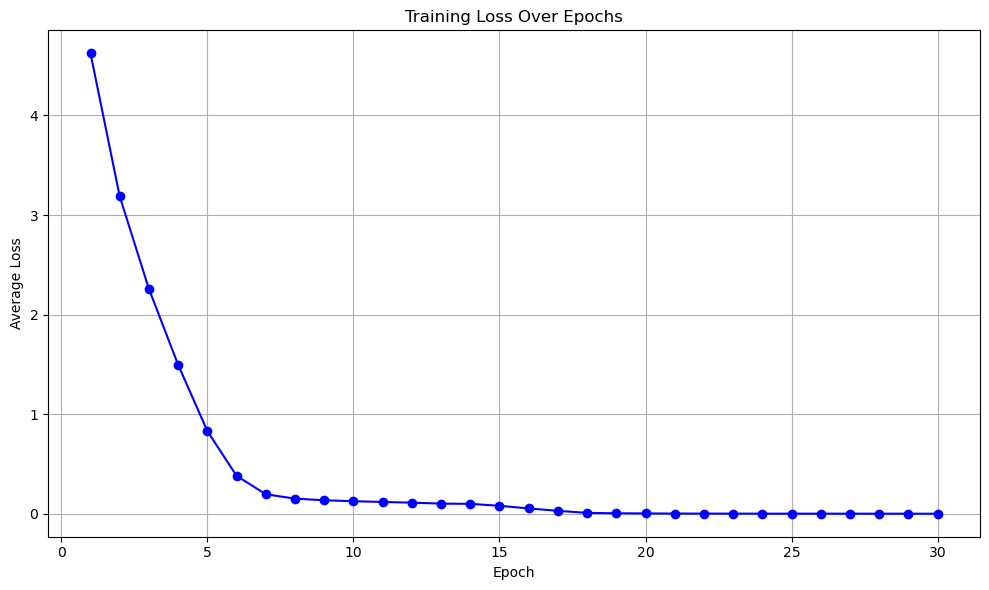

UnsupportedOperatorError: Exporting the operator 'aten::unflatten' to ONNX opset version 12 is not supported. Support for this operator was added in version 13, try exporting with this version.

In [1]:
import os
import torch
import open_clip
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import onnx

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CLIP model and tokenizer
model, preprocess, *_ = open_clip.create_model_and_transforms("ViT-B/32-quickgelu", pretrained="openai")
model = model.to(device)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

# Dataset path
dataset_path = r"D:\DataSet"

# Class labels for all 41 folders with specific descriptions
class_labels = [
    "small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027)",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-035)",
    "analog temperature sensor with black thermistor and two pins on green PCB (KY-013)",
    "arduino microcontroller board with blue PCB, USB port, and black IC chips (Uno)",
    "infrared obstacle avoidance sensor with two black IR LEDs and three pins on green PCB (KY-032)",
    "tilt ball switch sensor with metal ball in clear plastic tube on green PCB (KY-020)",
    "microphone sound detection sensor with small round silver mic on red PCB (KY-037)",
    "push button switch module with square black tactile button and four pins on green PCB (KY-004)",
    "active buzzer sound module with black cylindrical piezo and two pins on green PCB (KY-012)",
    "color flash LED module with flashing LED on green PCB (KY-0347)",
    "digital temperature sensor with black chip and three pins on green PCB (KY-028)",
    "ESP32 microcontroller board with black PCB and multiple pins",
    "ESP32 camera module with small camera lens and black PCB",
    "ESP8266 microcontroller board with black PCB and Wi-Fi antenna",
    "flame sensor with infrared receiver and three pins on green PCB (KY-026)",
    "GSM module with SIM card slot and antenna connector on green PCB",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-003)",
    "heartbeat sensor with finger clip and three pins on green PCB (KY-039)",
    "IR emission module with infrared LED and two pins on green PCB (KY-005)",
    "IR receiver module with black IR sensor and three pins on green PCB (KY-022)",
    "analog joystick controller with black joystick, two orange potentiometers, and five pins on green PCB (KY-023)",
    "laser emit module with red laser diode and three pins on green PCB (KY-008)",
    "light blocking sensor with slotted optical switch and three pins on green PCB (KY-010)",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-024)",
    "mini magnetic reed switch with small magnet and two pins on green PCB (KY-021)",
    "mini two-color LED module with red and green LED on green PCB (KY-029)",
    "photoresistor sensor with light-sensitive resistor and two pins on green PCB (KY-018)",
    "reed switch sensor with magnetic reed and two pins on green PCB (KY-025)",
    "electromagnetic relay module with blue relay, screw terminals, and red PCB (KY-019)",
    "multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-016)",
    "rotary encoder module with black knob and five pins on green PCB (KY-040)",
    "shock sensor with spring and two pins on green PCB (KY-002)",
    "microphone sound detection sensor with small round silver mic on red PCB (KY-038)",
    "multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-009)",
    "tap sensor module with vibration sensor and three pins on green PCB (KY-031)",
    "temperature sensor with black chip and three pins on green PCB (KY-001)",
    "temperature and humidity sensor with blue sensor and three pins on green PCB (KY-015)",
    "mercury tilt switch sensor with small glass tube containing silver mercury on green PCB (KY-017)",
    "capacitive touch sensor module with flat silver touch pad and three pins on green PCB (KY-036)",
    "tracking sensor with infrared sensor and three pins on green PCB (KY-033)",
    "two-color LED module with red and green LED on green PCB (KY-011)"
]

# Folder-to-label mapping for all 41 folders
folder_to_label = {
    '2pc light cup (ky-027)': 'small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027)',
    'analog hall (ky-035)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-035)',
    'analog temp (ky-013)': 'analog temperature sensor with black thermistor and two pins on green PCB (KY-013)',
    'arduino uno': 'arduino microcontroller board with blue PCB, USB port, and black IC chips (Uno)',
    'avoidance (ky-032)': 'infrared obstacle avoidance sensor with two black IR LEDs and three pins on green PCB (KY-032)',
    'ball switch (ky-020)': 'tilt ball switch sensor with metal ball in clear plastic tube on green PCB (KY-020)',
    'big sound (ky-037)': 'microphone sound detection sensor with small round silver mic on red PCB (KY-037)',
    'button (ky-004)': 'push button switch module with square black tactile button and four pins on green PCB (KY-004)',
    'buzzer (ky-012)': 'active buzzer sound module with black cylindrical piezo and two pins on green PCB (KY-012)',
    'color flash (ky-0347)': 'color flash LED module with flashing LED on green PCB (KY-0347)',
    'digital temperature (ky-028)': 'digital temperature sensor with black chip and three pins on green PCB (KY-028)',
    'esp 32': 'ESP32 microcontroller board with black PCB and multiple pins',
    'esp 32 camera': 'ESP32 camera module with small camera lens and black PCB',
    'esp 8266': 'ESP8266 microcontroller board with black PCB and Wi-Fi antenna',
    'flame (ky-026)': 'flame sensor with infrared receiver and three pins on green PCB (KY-026)',
    'gsm module': 'GSM module with SIM card slot and antenna connector on green PCB',
    'hall magnetic (ky-003)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-003)',
    'heartbeat (ky-039)': 'heartbeat sensor with finger clip and three pins on green PCB (KY-039)',
    'ir emission (ky-005)': 'IR emission module with infrared LED and two pins on green PCB (KY-005)',
    'ir receiver (ky-022)': 'IR receiver module with black IR sensor and three pins on green PCB (KY-022)',
    'joystick (ky-023)': 'analog joystick controller with black joystick, two orange potentiometers, and five pins on green PCB (KY-023)',
    'laser emit (ky-008)': 'laser emit module with red laser diode and three pins on green PCB (KY-008)',
    'light blocking (ky-010)': 'light blocking sensor with slotted optical switch and three pins on green PCB (KY-010)',
    'linear hall (ky-024)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-024)',
    'mini switch (ky-021)': 'mini magnetic reed switch with small magnet and two pins on green PCB (KY-021)',
    'mini two-colour(ky-029)': 'mini two-color LED module with red and green LED on green PCB (KY-029)',
    'photoresistor (ky-018)': 'photoresistor sensor with light-sensitive resistor and two pins on green PCB (KY-018)',
    'reed switch (ky-025)': 'reed switch sensor with magnetic reed and two pins on green PCB (KY-025)',
    'relay (ky-019)': 'electromagnetic relay module with blue relay, screw terminals, and red PCB (KY-019)',
    'rgb led (ky-016)': 'multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-016)',
    'rotay encoders (ky-040)': 'rotary encoder module with black knob and five pins on green PCB (KY-040)',
    'shock (ky-002)': 'shock sensor with spring and two pins on green PCB (KY-002)',
    'small sound (ky-038)': 'microphone sound detection sensor with small round silver mic on red PCB (KY-038)',
    'smd rgb (ky-009)': 'multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-009)',
    'tap module (ky-031)': 'tap sensor module with vibration sensor and three pins on green PCB (KY-031)',
    'temp 18b20 (ky-001)': 'temperature sensor with black chip and three pins on green PCB (KY-001)',
    'temp and humidity (ky-015)': 'temperature and humidity sensor with blue sensor and three pins on green PCB (KY-015)',
    'tilt switch (ky-017)': 'mercury tilt switch sensor with small glass tube containing silver mercury on green PCB (KY-017)',
    'touch (ky-036)': 'capacitive touch sensor module with flat silver touch pad and three pins on green PCB (KY-036)',
    'tracking (ky-033)': 'tracking sensor with infrared sensor and three pins on green PCB (KY-033)',
    'two-colour(ky-011)': 'two-color LED module with red and green LED on green PCB (KY-011)'
}

# Debugging dataset structure
subfolders = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print(f"Found {len(subfolders)} subfolders in {dataset_path}: {subfolders}")

# Prepare few-shot training data
train_images = []
train_labels = []

for sensor in subfolders:
    sensor_path = os.path.join(dataset_path, sensor)
    actual_label = folder_to_label[sensor.lower()]
    label_idx = class_labels.index(actual_label)
    
    image_paths = [os.path.join(sensor_path, img) for img in os.listdir(sensor_path) if img.endswith((".jpg", ".png"))]
    # Use up to 5 images per class for few-shot training
    for img_path in image_paths[:5]:
        try:
            image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            train_images.append(image)
            train_labels.append(label_idx)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

# Convert to tensors
train_images = torch.cat(train_images, dim=0)
train_labels = torch.tensor(train_labels, dtype=torch.long).to(device)

# Fine-tune CLIP
model.train()
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

num_epochs = 30
batch_size = 32
epoch_losses = []  # List to store loss per epoch

for epoch in range(num_epochs):
    model.zero_grad()
    total_loss = 0
    for i in range(0, len(train_images), batch_size):
        batch_images = train_images[i:i+batch_size]
        batch_labels = train_labels[i:i+batch_size]
        
        with torch.set_grad_enabled(True):
            image_features = model.encode_image(batch_images)
            text_features = model.encode_text(tokenizer(class_labels).to(device))
            logits = (image_features @ text_features.T)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            model.zero_grad()
            total_loss += loss.item()
    avg_loss = total_loss / (len(train_images) // batch_size + 1)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f} (Avg: {avg_loss:.4f})")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Export model to ONNX
model.eval()
dummy_image = torch.randn(1, 3, 224, 224).to(device)  # Dummy input for image
dummy_text = tokenizer(class_labels[:1]).to(device)  # Dummy input for text (single label)

# Define dynamic axes for variable batch sizes
dynamic_axes = {
    'image_input': {0: 'batch_size'},
    'text_input': {0: 'batch_size'},
    'image_output': {0: 'batch_size'},
    'text_output': {0: 'batch_size'}
}

# Export the model
onnx_path = "clip_finetuned.onnx"
torch.onnx.export(
    model,
    (dummy_image, dummy_text),
    onnx_path,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['image_input', 'text_input'],
    output_names=['image_output', 'text_output'],
    dynamic_axes=dynamic_axes
)
print(f"Model exported to {onnx_path}")


# Switch to evaluation mode
model.eval()

# Function to classify images
def classify_sensor_images(sensor_folder, text_features):
    image_paths = [os.path.join(sensor_folder, img) for img in os.listdir(sensor_folder) if img.endswith((".jpg", ".png"))]
    scores = []

    for img_path in image_paths:
        try:
            image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            with torch.no_grad():
                image_features = model.encode_image(image)
                similarity = (image_features @ text_features.T).softmax(dim=-1)
            scores.append(similarity.squeeze().cpu().numpy())
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    if not scores:
        print(f"No valid images in {sensor_folder}")
        return class_labels[0]  # Default to first class if no images
    avg_scores = np.mean(scores, axis=0)
    print(f"Scores for {sensor_folder}: {avg_scores}")
    return class_labels[np.argmax(avg_scores)]

# Tokenize and encode text features for evaluation
text_inputs = tokenizer(class_labels).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_inputs)

# Classification
results = {}
true_labels = []
predicted_labels = []

for sensor in subfolders:
    sensor_path = os.path.join(dataset_path, sensor)
    actual_label = folder_to_label[sensor.lower()]
    predicted_class = classify_sensor_images(sensor_path, text_features)
    results[sensor] = predicted_class
    true_labels.append(actual_label)
    predicted_labels.append(predicted_class)
    print(f"Folder: {sensor}, Actual: {actual_label}, Predicted: {predicted_class}")

# Debugging
print("\nTrue Labels Count:", len(true_labels))
print("Unique True Labels:", set(true_labels))
print("Unique Predicted Labels:", set(predicted_labels))

# Evaluation
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=class_labels)
plt.figure(figsize=(15, 12))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=90)
plt.yticks(range(len(class_labels)), class_labels)
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
plt.tight_layout()
plt.show()

In [5]:
# Export model to ONNX
model.eval()
dummy_image = torch.randn(1, 3, 224, 224).to(device)  # Dummy input for image
dummy_text = tokenizer(class_labels[:1]).to(device)  # Dummy input for text (single label)

# Define dynamic axes for variable batch sizes
dynamic_axes = {
    'image_input': {0: 'batch_size'},
    'text_input': {0: 'batch_size'},
    'image_output': {0: 'batch_size'},
    'text_output': {0: 'batch_size'}
}

# Export the model
onnx_path = "clip_finetuned.onnx"
try:
    torch.onnx.export(
        model,
        (dummy_image, dummy_text),
        onnx_path,
        export_params=True,
        opset_version=14,  # Updated to opset 14 to support aten::scaled_dot_product_attention
        do_constant_folding=True,
        input_names=['image_input', 'text_input'],
        output_names=['image_output', 'text_output'],
        dynamic_axes=dynamic_axes
    )
    print(f"Model exported successfully to {onnx_path}")
except Exception as e:
    print(f"Error during ONNX export: {e}")
    print("Suggestions: Try opset_version=15, disable do_constant_folding, or export only the vision encoder.")

# Verify ONNX model
try:
    if os.path.exists(onnx_path):
        onnx_model = onnx.load(onnx_path)
        onnx.checker.check_model(onnx_model)
        print("ONNX model verified successfully")
    else:
        print(f"ONNX model file {onnx_path} not found. Export likely failed.")
except Exception as e:
    print(f"Error verifying ONNX model: {e}")

C:\Users\Namo\anaconda3\Lib\site-packages\torch\onnx\symbolic_opset9.py:5383: UserWarning: Exporting aten::index operator of advanced indexing in opset 14 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


Model exported successfully to clip_finetuned.onnx
ONNX model verified successfully


Found 41 subfolders in D:\DataSet: ['2Pc Light Cup (KY-027)', 'Analog Hall (KY-035)', 'Analog Temp (KY-013)', 'Arduino Uno', 'Avoidance (KY-032)', 'Ball Switch (KY-020)', 'Big Sound (KY-037)', 'Button (KY-004)', 'Buzzer (KY-012)', 'Color Flash (KY-0347)', 'Digital Temperature (KY-028)', 'ESP 32', 'ESP 32 Camera', 'ESP 8266', 'Flame (KY-026)', 'GSM Module', 'Hall Magnetic (KY-003)', 'Heartbeat (KY-039)', 'IR Emission (KY-005)', 'IR receiver (KY-022)', 'Joystick (KY-023)', 'Laser Emit (KY-008)', 'Light Blocking (KY-010)', 'Linear Hall (KY-024)', 'Mini Switch (KY-021)', 'Mini Two-Colour(KY-029)', 'Photoresistor (KY-018)', 'Reed Switch (KY-025)', 'Relay (KY-019)', 'RGB LED (KY-016)', 'Rotay Encoders (KY-040)', 'Shock (KY-002)', 'Small Sound (KY-038)', 'SMD RGB (KY-009)', 'Tap Module (KY-031)', 'Temp 18B20 (KY-001)', 'Temp and Humidity (KY-015)', 'Tilt Switch (KY-017)', 'Touch (KY-036)', 'Tracking (KY-033)', 'Two-Colour(KY-011)']
Epoch 1/25, Loss: 18.5351 (Avg: 4.6338)
Epoch 2/25, Loss: 12.

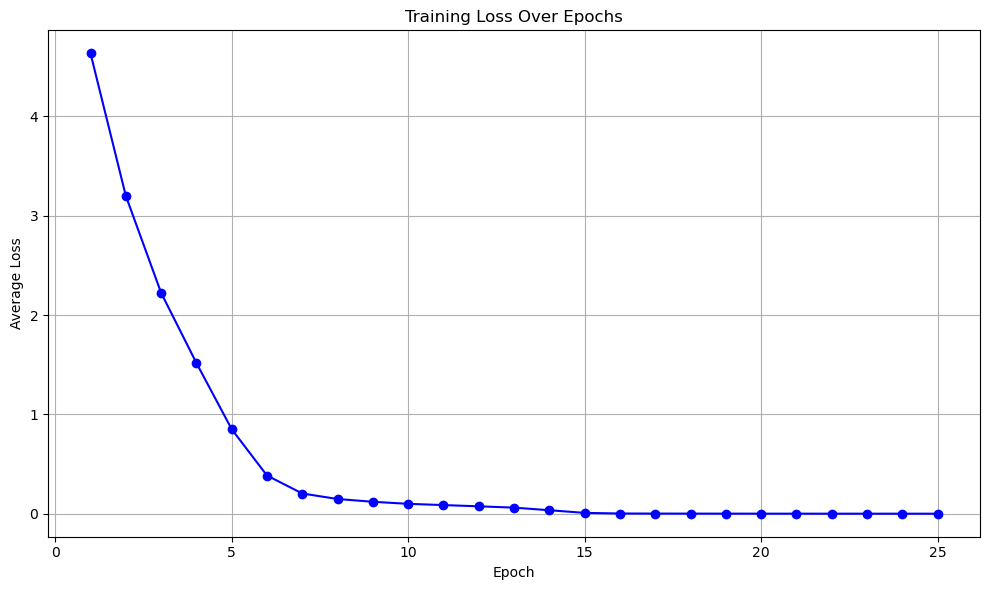

Scores for D:\DataSet\2Pc Light Cup (KY-027): [6.7397606e-01 2.3539113e-03 4.2238324e-03 1.3126775e-05 8.0226286e-04
 3.0623778e-04 1.1514624e-04 1.5156912e-02 1.6532361e-03 4.0688654e-03
 8.6341230e-03 2.9256209e-03 3.6345016e-02 2.1061910e-04 2.4327911e-03
 9.2468865e-04 2.5838928e-03 4.5213714e-02 1.8380558e-04 4.2256368e-03
 1.6533516e-04 2.0649254e-03 9.0279859e-03 2.7397145e-02 5.2385922e-03
 2.1652519e-03 5.2012340e-03 3.1453401e-03 3.2808207e-04 4.3877758e-04
 5.0958853e-02 8.9949835e-03 5.6819676e-04 1.9360194e-04 3.5168417e-02
 2.5818457e-03 1.0613809e-05 3.5047296e-02 4.0181596e-03 6.7230634e-05
 8.6867588e-04]
Folder: 2Pc Light Cup (KY-027), Actual: small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027), Predicted: small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027)
Scores for D:\DataSet\Analog Hall (KY-035): [1.6344569e-07 9.4112957e-01 8.3982559e-06 1.7486258e-08 1.6247523e-06
 1.8443235e-07 2.7819598e-07 9.3471826e

C:\Users\Namo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Namo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Namo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


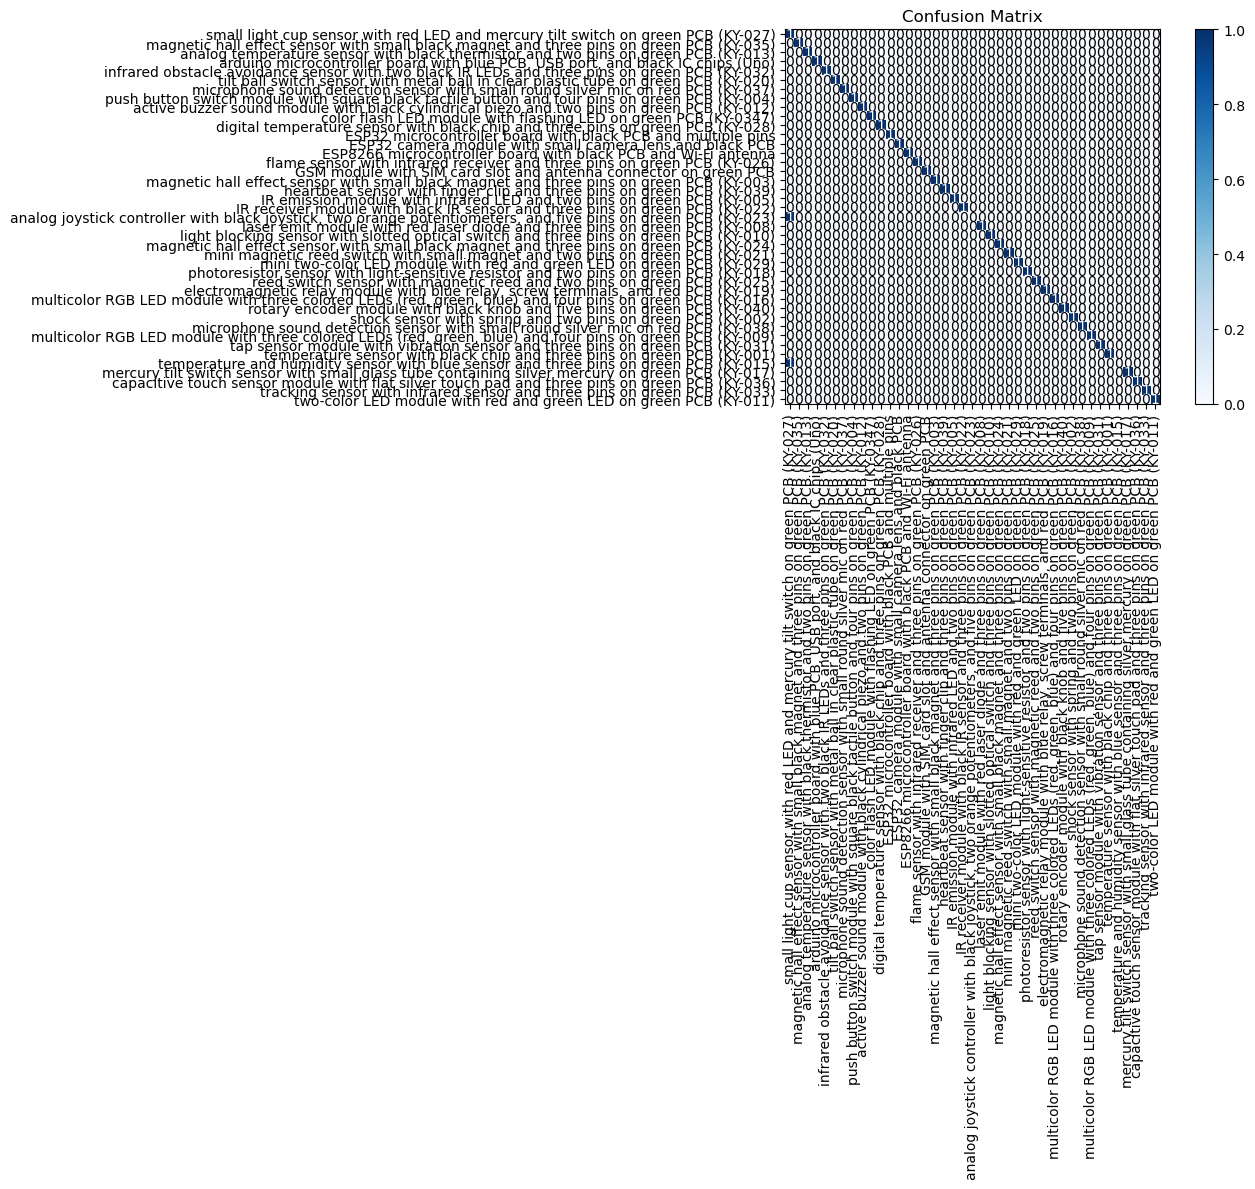

In [3]:
import os
import torch
import open_clip
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CLIP model and tokenizer
model, preprocess, *_ = open_clip.create_model_and_transforms("ViT-B/32-quickgelu", pretrained="openai")
model = model.to(device)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

# Dataset path
dataset_path = r"D:\DataSet"

# Class labels for all 41 folders with specific descriptions
class_labels = [
    "small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027)",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-035)",
    "analog temperature sensor with black thermistor and two pins on green PCB (KY-013)",
    "arduino microcontroller board with blue PCB, USB port, and black IC chips (Uno)",
    "infrared obstacle avoidance sensor with two black IR LEDs and three pins on green PCB (KY-032)",
    "tilt ball switch sensor with metal ball in clear plastic tube on green PCB (KY-020)",
    "microphone sound detection sensor with small round silver mic on red PCB (KY-037)",
    "push button switch module with square black tactile button and four pins on green PCB (KY-004)",
    "active buzzer sound module with black cylindrical piezo and two pins on green PCB (KY-012)",
    "color flash LED module with flashing LED on green PCB (KY-0347)",
    "digital temperature sensor with black chip and three pins on green PCB (KY-028)",
    "ESP32 microcontroller board with black PCB and multiple pins",
    "ESP32 camera module with small camera lens and black PCB",
    "ESP8266 microcontroller board with black PCB and Wi-Fi antenna",
    "flame sensor with infrared receiver and three pins on green PCB (KY-026)",
    "GSM module with SIM card slot and antenna connector on green PCB",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-003)",
    "heartbeat sensor with finger clip and three pins on green PCB (KY-039)",
    "IR emission module with infrared LED and two pins on green PCB (KY-005)",
    "IR receiver module with black IR sensor and three pins on green PCB (KY-022)",
    "analog joystick controller with black joystick, two orange potentiometers, and five pins on green PCB (KY-023)",
    "laser emit module with red laser diode and three pins on green PCB (KY-008)",
    "light blocking sensor with slotted optical switch and three pins on green PCB (KY-010)",
    "magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-024)",
    "mini magnetic reed switch with small magnet and two pins on green PCB (KY-021)",
    "mini two-color LED module with red and green LED on green PCB (KY-029)",
    "photoresistor sensor with light-sensitive resistor and two pins on green PCB (KY-018)",
    "reed switch sensor with magnetic reed and two pins on green PCB (KY-025)",
    "electromagnetic relay module with blue relay, screw terminals, and red PCB (KY-019)",
    "multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-016)",
    "rotary encoder module with black knob and five pins on green PCB (KY-040)",
    "shock sensor with spring and two pins on green PCB (KY-002)",
    "microphone sound detection sensor with small round silver mic on red PCB (KY-038)",
    "multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-009)",
    "tap sensor module with vibration sensor and three pins on green PCB (KY-031)",
    "temperature sensor with black chip and three pins on green PCB (KY-001)",
    "temperature and humidity sensor with blue sensor and three pins on green PCB (KY-015)",
    "mercury tilt switch sensor with small glass tube containing silver mercury on green PCB (KY-017)",
    "capacitive touch sensor module with flat silver touch pad and three pins on green PCB (KY-036)",
    "tracking sensor with infrared sensor and three pins on green PCB (KY-033)",
    "two-color LED module with red and green LED on green PCB (KY-011)"
]

# Folder-to-label mapping for all 41 folders
folder_to_label = {
    '2pc light cup (ky-027)': 'small light cup sensor with red LED and mercury tilt switch on green PCB (KY-027)',
    'analog hall (ky-035)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-035)',
    'analog temp (ky-013)': 'analog temperature sensor with black thermistor and two pins on green PCB (KY-013)',
    'arduino uno': 'arduino microcontroller board with blue PCB, USB port, and black IC chips (Uno)',
    'avoidance (ky-032)': 'infrared obstacle avoidance sensor with two black IR LEDs and three pins on green PCB (KY-032)',
    'ball switch (ky-020)': 'tilt ball switch sensor with metal ball in clear plastic tube on green PCB (KY-020)',
    'big sound (ky-037)': 'microphone sound detection sensor with small round silver mic on red PCB (KY-037)',
    'button (ky-004)': 'push button switch module with square black tactile button and four pins on green PCB (KY-004)',
    'buzzer (ky-012)': 'active buzzer sound module with black cylindrical piezo and two pins on green PCB (KY-012)',
    'color flash (ky-0347)': 'color flash LED module with flashing LED on green PCB (KY-0347)',
    'digital temperature (ky-028)': 'digital temperature sensor with black chip and three pins on green PCB (KY-028)',
    'esp 32': 'ESP32 microcontroller board with black PCB and multiple pins',
    'esp 32 camera': 'ESP32 camera module with small camera lens and black PCB',
    'esp 8266': 'ESP8266 microcontroller board with black PCB and Wi-Fi antenna',
    'flame (ky-026)': 'flame sensor with infrared receiver and three pins on green PCB (KY-026)',
    'gsm module': 'GSM module with SIM card slot and antenna connector on green PCB',
    'hall magnetic (ky-003)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-003)',
    'heartbeat (ky-039)': 'heartbeat sensor with finger clip and three pins on green PCB (KY-039)',
    'ir emission (ky-005)': 'IR emission module with infrared LED and two pins on green PCB (KY-005)',
    'ir receiver (ky-022)': 'IR receiver module with black IR sensor and three pins on green PCB (KY-022)',
    'joystick (ky-023)': 'analog joystick controller with black joystick, two orange potentiometers, and five pins on green PCB (KY-023)',
    'laser emit (ky-008)': 'laser emit module with red laser diode and three pins on green PCB (KY-008)',
    'light blocking (ky-010)': 'light blocking sensor with slotted optical switch and three pins on green PCB (KY-010)',
    'linear hall (ky-024)': 'magnetic hall effect sensor with small black magnet and three pins on green PCB (KY-024)',
    'mini switch (ky-021)': 'mini magnetic reed switch with small magnet and two pins on green PCB (KY-021)',
    'mini two-colour(ky-029)': 'mini two-color LED module with red and green LED on green PCB (KY-029)',
    'photoresistor (ky-018)': 'photoresistor sensor with light-sensitive resistor and two pins on green PCB (KY-018)',
    'reed switch (ky-025)': 'reed switch sensor with magnetic reed and two pins on green PCB (KY-025)',
    'relay (ky-019)': 'electromagnetic relay module with blue relay, screw terminals, and red PCB (KY-019)',
    'rgb led (ky-016)': 'multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-016)',
    'rotay encoders (ky-040)': 'rotary encoder module with black knob and five pins on green PCB (KY-040)',
    'shock (ky-002)': 'shock sensor with spring and two pins on green PCB (KY-002)',
    'small sound (ky-038)': 'microphone sound detection sensor with small round silver mic on red PCB (KY-038)',
    'smd rgb (ky-009)': 'multicolor RGB LED module with three colored LEDs (red, green, blue) and four pins on green PCB (KY-009)',
    'tap module (ky-031)': 'tap sensor module with vibration sensor and three pins on green PCB (KY-031)',
    'temp 18b20 (ky-001)': 'temperature sensor with black chip and three pins on green PCB (KY-001)',
    'temp and humidity (ky-015)': 'temperature and humidity sensor with blue sensor and three pins on green PCB (KY-015)',
    'tilt switch (ky-017)': 'mercury tilt switch sensor with small glass tube containing silver mercury on green PCB (KY-017)',
    'touch (ky-036)': 'capacitive touch sensor module with flat silver touch pad and three pins on green PCB (KY-036)',
    'tracking (ky-033)': 'tracking sensor with infrared sensor and three pins on green PCB (KY-033)',
    'two-colour(ky-011)': 'two-color LED module with red and green LED on green PCB (KY-011)'
}

# Debugging dataset structure
subfolders = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print(f"Found {len(subfolders)} subfolders in {dataset_path}: {subfolders}")

# Prepare few-shot training data
train_images = []
train_labels = []

for sensor in subfolders:
    sensor_path = os.path.join(dataset_path, sensor)
    actual_label = folder_to_label[sensor.lower()]
    label_idx = class_labels.index(actual_label)
    
    image_paths = [os.path.join(sensor_path, img) for img in os.listdir(sensor_path) if img.endswith((".jpg", ".png"))]
    # Use up to 5 images per class for few-shot training
    for img_path in image_paths[:5]:
        try:
            image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            train_images.append(image)
            train_labels.append(label_idx)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

# Convert to tensors
train_images = torch.cat(train_images, dim=0)
train_labels = torch.tensor(train_labels, dtype=torch.long).to(device)

# Fine-tune CLIP
model.train()
optimizer = optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

num_epochs = 25
batch_size = 32
epoch_losses = []  # List to store loss per epoch

for epoch in range(num_epochs):
    model.zero_grad()
    total_loss = 0
    for i in range(0, len(train_images), batch_size):
        batch_images = train_images[i:i+batch_size]
        batch_labels = train_labels[i:i+batch_size]
        
        with torch.set_grad_enabled(True):
            image_features = model.encode_image(batch_images)
            text_features = model.encode_text(tokenizer(class_labels).to(device))
            logits = (image_features @ text_features.T)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            model.zero_grad()
            total_loss += loss.item()
    avg_loss = total_loss / (len(train_images) // batch_size + 1)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f} (Avg: {avg_loss:.4f})")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Switch to evaluation mode
model.eval()

# Function to classify images
def classify_sensor_images(sensor_folder, text_features):
    image_paths = [os.path.join(sensor_folder, img) for img in os.listdir(sensor_folder) if img.endswith((".jpg", ".png"))]
    scores = []

    for img_path in image_paths:
        try:
            image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
            with torch.no_grad():
                image_features = model.encode_image(image)
                similarity = (image_features @ text_features.T).softmax(dim=-1)
            scores.append(similarity.squeeze().cpu().numpy())
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

    if not scores:
        print(f"No valid images in {sensor_folder}")
        return class_labels[0]  # Default to first class if no images
    avg_scores = np.mean(scores, axis=0)
    print(f"Scores for {sensor_folder}: {avg_scores}")
    return class_labels[np.argmax(avg_scores)]

# Tokenize and encode text features for evaluation
text_inputs = tokenizer(class_labels).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_inputs)

# Classification
results = {}
true_labels = []
predicted_labels = []

for sensor in subfolders:
    sensor_path = os.path.join(dataset_path, sensor)
    actual_label = folder_to_label[sensor.lower()]
    predicted_class = classify_sensor_images(sensor_path, text_features)
    results[sensor] = predicted_class
    true_labels.append(actual_label)
    predicted_labels.append(predicted_class)
    print(f"Folder: {sensor}, Actual: {actual_label}, Predicted: {predicted_class}")

# Debugging
print("\nTrue Labels Count:", len(true_labels))
print("Unique True Labels:", set(true_labels))
print("Unique Predicted Labels:", set(predicted_labels))

# Evaluation
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))


# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=class_labels)
plt.figure(figsize=(15, 12))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=90)
plt.yticks(range(len(class_labels)), class_labels)
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
plt.tight_layout()
plt.show()